In [13]:
# overall title: "Data Visualization and Analysis for Guitar MIDI Dataset"
# This notebook contains several blocks of code for visualizing and analyzing the Guitar MIDI dataset. It includes:
# 1. An interactive dataset browser that allows you to view examples grouped by label and flip through them.
# 2. A block that computes and visualizes the mean and local contrast of chunk maxes for active notes in 6-note polyphony examples.
# 3. A block that does the same for non-active notes, to identify potential confounding factors or noise patterns.
# 4. A block that computes and visualizes the variance of chunk maxes for active notes in 3-note polyphony examples, along with the mean for reference.
import tensorflow as tf
import os
import glob,re
import random
from common import feature_description,INPUT_SHAPE,OUTPUT_DIM_NOTES,filter_polyphony
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import common
from common import feature_description
from matplotlib.colors import LogNorm
input_data_dir = ['/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/training_subset_electric','/training_cache/training_subset_electric']#'/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'
#input_data_dir='/data2/training_subset'
input_filepaths=[]
for dir in input_data_dir:
    input_filepaths.extend(glob.glob(os.path.join(dir, '**', '*.tfrecord'), recursive=True))
input_filepaths = sorted(input_filepaths,key=lambda file: int(re.findall('\\d+',os.path.basename(file))[0]) )
print("Total number of TFRecord files found:", len(input_filepaths))
# input_filepaths = ['/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_00028.tfrecord',
#                    '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_63989.tfrecord',
#                    '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/training_subset/filtered_poly_data_63819.tfrecord']# 
random.shuffle(input_filepaths)
# input_filepaths=input_filepaths[:1000]
print("Number records found ",len(input_filepaths))

def parse_batch(serialized_batch):
    parsed = tf.io.parse_single_example(serialized_batch, feature_description)
    input_raw = tf.io.decode_raw(parsed["input"], tf.int8)
    label_raw = tf.io.decode_raw(parsed["output"], tf.int8)
    
    input_tensor = tf.reshape(input_raw, INPUT_SHAPE)
    input_tensor = tf.cast(input_tensor, tf.float32)
    input_tensor=input_tensor/127
    output_tensor = tf.cast(tf.reshape(label_raw, [OUTPUT_DIM_NOTES]), tf.float32)
    return input_tensor,output_tensor#input_raw,label_raw

def create_dataset(filepaths, batch_size=256):
    # Convert file list to a dataset of strings
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    
    # Read from multiple files in parallel
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=True
    )
    
    # Batch the RAW serialized protos FIRST
    # dataset = dataset.batch(batch_size)
    

    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE,deterministic=True)
    return dataset.prefetch(tf.data.AUTOTUNE)



Total number of TFRecord files found: 11341
Number records found  11341


In [6]:
# dataset=create_dataset(input_filepaths)

# dataset=filter_polyphony(dataset,2,True)
# dataset_size=2001000#sum(1 for _ in dataset)

# print("Dataset size",dataset_size)

# from common import count_concurrent_notes_distribution,plot_histogram

# hist=count_concurrent_notes_distribution(dataset)
# plot_histogram(hist[:10],10)
# plot_histogram(hist)

first 10 unique amplitudes: [0.         0.00787402 0.01574803 0.02362205 0.03149606 0.03937008
 0.04724409 0.05511811 0.06299213 0.07086615]
min step: 0.007874  (1/255=0.003922)
0.0004222972972972973


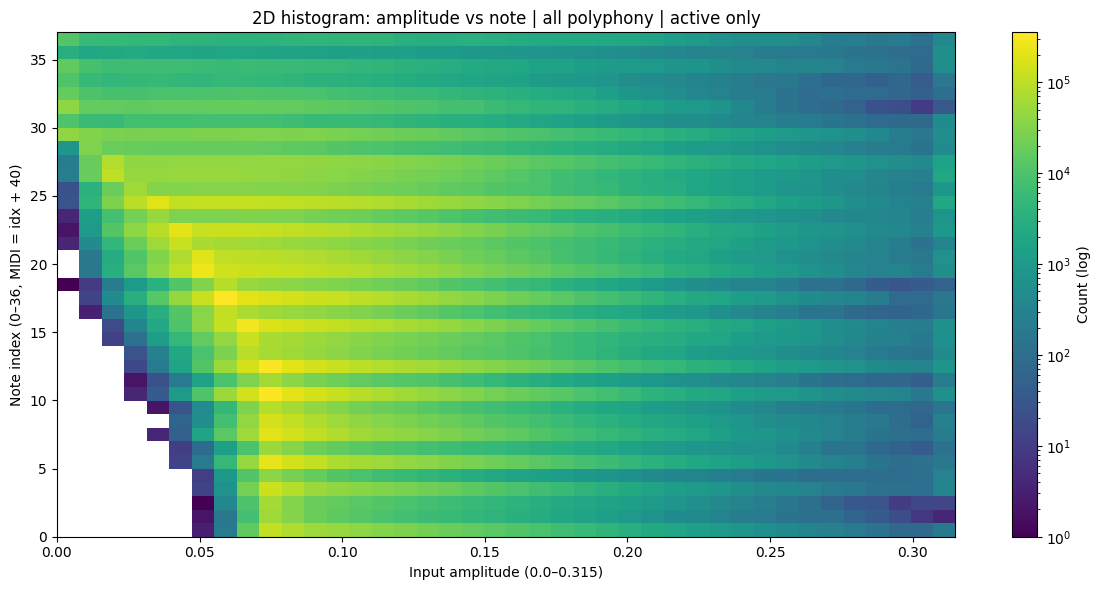

In [16]:
# 2d Histogram of the of  input amplitude values over the labels for active notes and all polyphony levels.
# the histogram is a heatmap where the x-axis represents the input amplitude values (0-127) and the y-axis represents the note labels (0-127). The color intensity at each (x, y) coordinate indicates the frequency of that amplitude value for that note label across the dataset. This visualization helps to identify patterns in how different amplitude values are distributed across various note labels, which can be useful for understanding the characteristics of the dataset and for feature engineering in machine learning models.
def plot_2d_histogram(dataset, polyphony_level=None, active_notes_only=True):
    N_NOTES = 37
    AMP_MAX = 0.3
    SRC_LEVELS = 127  # assume input is uint8/255; change if different
    N_BINS = int(np.ceil(AMP_MAX * SRC_LEVELS)) + 1
    histogram = np.zeros((N_NOTES, N_BINS), dtype=np.int64)

    sample_printed = False

    for input_tensor, output_tensor in dataset:
        x = input_tensor.numpy()
        y = output_tensor.numpy()

        if y.shape[-1] == OUTPUT_DIM_NOTES:
            y = y[:, 40:77]
        assert y.shape[-1] == N_NOTES, f"unexpected label shape {y.shape}"

        if polyphony_level is not None:
            keep = y.sum(axis=-1) == polyphony_level
            if not keep.any():
                continue
            x, y = x[keep], y[keep]

        x_max = x.max(axis=2)
        x_max = x_max.reshape(x_max.shape[0], N_NOTES, 4).max(-1)

        if not sample_printed:
            uniq = np.unique(x_max)
            print(f"first 10 unique amplitudes: {uniq[:10]}")
            if len(uniq) > 1:
                print(f"min step: {np.diff(uniq).min():.6f}  (1/255={1/255:.6f})")
            sample_printed = True
            print((x_max >= AMP_MAX).mean())


        amp_q = np.clip(np.round(x_max * SRC_LEVELS).astype(np.int64), 0, N_BINS - 1)

        mask = y.astype(bool) if active_notes_only else np.ones_like(y, dtype=bool)
        note_idx = np.broadcast_to(np.arange(N_NOTES), amp_q.shape)
        np.add.at(histogram, (note_idx[mask], amp_q[mask]), 1)

    plt.figure(figsize=(12, 6))
    plt.imshow(histogram, aspect='auto', origin='lower', cmap='viridis',
               extent=[0.0, N_BINS / SRC_LEVELS, 0, N_NOTES],
               norm=LogNorm(vmin=1, vmax=max(histogram.max(), 1)))
    plt.colorbar(label='Count (log)')
    plt.xlabel(f'Input amplitude (0.0–{N_BINS/SRC_LEVELS:.3f})')
    plt.ylabel('Note index (0–36, MIDI = idx + 40)')
    title = '2D histogram: amplitude vs note'
    title += f' | poly={polyphony_level}' if polyphony_level is not None else ' | all polyphony'
    title += ' | active only' if active_notes_only else ' | all notes'
    plt.title(title)
    plt.tight_layout()
    plt.show()


dataset=create_dataset(input_filepaths)
#filtered_dataset=filter_polyphony(dataset,6,True,has_filtered_audio=True)
plot_2d_histogram(dataset.batch(1024), polyphony_level=None, active_notes_only=True)

In [ ]:
# title: "Interactive Dataset Browser by Label"
# this block is for interactively browsing the dataset, showing all examples with the same label together, and allowing to flip through them. It also shows an overview of all examples with the same label on the right (max over time).
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import common
from common import feature_description

# # %%
# tfrecord_files = tf.io.gfile.glob("*.tfrecord")  # adjust path
# dataset = tf.data.TFRecordDataset(input_filepaths)

# def parse_example(example_proto):
#     parsed = tf.io.parse_single_example(example_proto, feature_description)
#     audio = tf.reshape(parsed['audio'], (148, 256))
#     label = parsed['label']  # vector
#     return audio, label

dataset =create_dataset(input_filepaths)
dataset=filter_polyphony(dataset,4,True,has_filtered_audio=True)
# %% [markdown]
# ## Build label index

# %%
print("Indexing dataset by label...")
label_key_to_indices = {}  # tuple(label) -> [global_indices]
label_key_to_vector = {}   # tuple(label) -> np.array

for i, (audio, label) in enumerate(dataset):
    lv = label.numpy()
    key = tuple(lv)
    if key not in label_key_to_indices:
        label_key_to_indices[key] = []
        label_key_to_vector[key] = lv
    label_key_to_indices[key].append(i)
    if i % 100000 == 0:
        print(f"  scanned {i} examples...")

unique_keys = sorted(label_key_to_indices.keys())
print(f"Done. {len(unique_keys)} unique labels, {i+1} total examples.")

# %% [markdown]
# ## Interactive Browser

# %%
label_slider = widgets.IntSlider(
    value=0, min=0, max=len(unique_keys) - 1, step=1,
    description='Label #:',
    continuous_update=False
)

instance_slider = widgets.IntSlider(
    value=0, min=0, max=0, step=1,
    description='Instance:',
    continuous_update=False
)

def get_by_index(dataset, idx):
    for i,(audio,label) in enumerate(dataset):
        if i==idx:
            return audio,label
    return None


# Buttons for label slider
label_left = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
label_right = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))

# Buttons for instance slider
inst_left = widgets.Button(description='◀', layout=widgets.Layout(width='40px'))
inst_right = widgets.Button(description='▶', layout=widgets.Layout(width='40px'))

def label_left_click(b):
    if label_slider.value > label_slider.min:
        label_slider.value -= 1

def label_right_click(b):
    if label_slider.value < label_slider.max:
        label_slider.value += 1

def inst_left_click(b):
    if instance_slider.value > instance_slider.min:
        instance_slider.value -= 1

def inst_right_click(b):
    if instance_slider.value < instance_slider.max:
        instance_slider.value += 1

label_left.on_click(label_left_click)
label_right.on_click(label_right_click)
inst_left.on_click(inst_left_click)
inst_right.on_click(inst_right_click)

info_label = widgets.Label(value="")
label_display = widgets.Label(value="")
output = widgets.Output()

def lowest_active(key):
    positions = [i for i, v in enumerate(key) if v == 1]
    return positions[0] if positions else float('inf')

unique_keys = sorted(label_key_to_indices.keys(), key=lowest_active)

# Add a global dict to store vmin/vmax per label
label_vrange = {}

label_overview = {}

def on_label_change(change):
    key = unique_keys[label_slider.value]
    vec = label_key_to_vector[key]
    n = len(label_key_to_indices[key])
    instance_slider.max = n - 1
    instance_slider.value = 0
    info_label.value = f"{n} examples"
    active_positions = list(np.where(vec == 1)[0])
    label_display.value = f"Active positions: {active_positions} (lowest: {active_positions[0] if active_positions else 'none'})"

    indices = label_key_to_indices[key]
    vmin, vmax = float('inf'), float('-inf')
    overview_cols = []
    for idx in indices:
        example = dataset.skip(idx).take(1)
        audio, _ = next(iter(example))
        a = audio.numpy()
        vmin = min(vmin, a.min())
        vmax = max(vmax, a.max())
        overview_cols.append(a.max(axis=1))

    label_vrange[label_slider.value] = (vmin, vmax)
    label_overview[label_slider.value] = np.stack(overview_cols, axis=1)

    show_image(None)

def show_image(change):
    key = unique_keys[label_slider.value]
    global_idx = label_key_to_indices[key][instance_slider.value]

    example = dataset.skip(global_idx).take(1)
    audio, lbl = next(iter(example))
    audio_np = audio.numpy()

    vmin, vmax = label_vrange.get(label_slider.value, (audio_np.min(), audio_np.max()))
    overview = label_overview.get(label_slider.value)

    with output:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [3, 2]})

        ax = axes[0]
        im = ax.imshow(audio_np, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        ax.set_title(f"Label #{label_slider.value} | Inst {instance_slider.value}/{instance_slider.max} | idx: {global_idx}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Frequency")
        plt.colorbar(im, ax=ax)

        ax2 = axes[1]
        im2 = ax2.imshow(overview, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
        ax2.axvline(x=instance_slider.value, color='cyan', linewidth=2, linestyle='--')
        ax2.set_title(f"All {overview.shape[1]} instances (max over time)")
        ax2.set_xlabel("Instance")
        ax2.set_ylabel("Frequency")
        plt.colorbar(im2, ax=ax2)

        plt.tight_layout()
        plt.show()



label_slider.observe(on_label_change, names='value')
instance_slider.observe(show_image, names='value')

display(widgets.VBox([
    widgets.HBox([label_left, label_slider, label_right]),
    label_display,
    widgets.HBox([inst_left, instance_slider, inst_right, info_label]),
    output
]))

on_label_change({'new': 0})


Indexing dataset by label...
  scanned 0 examples...


KeyboardInterrupt: 

In [ ]:
# title: "Per-note variance of chunk maxes (3-note polyphony)"
# This block computes, for each note (label 40..76), the variance of the max values in each frequency chunk across all examples where that note is active. 
# It also computes the mean for reference. The resulting images show which chunks are most consistently strong (low variance) or variable (high variance) when a particular note is active.
import numpy as np
dataset =create_dataset(input_filepaths)
dataset=filter_polyphony(dataset,3,True,has_filtered_audio=True)
# For each note (label 40..76), collect chunk maxes across all examples where that note is active
note_chunks = {i: [] for i in range(37)}  # note_chunks[i] -> list of (37,4) max vectors

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)  # (148,)
    label_sub = label.numpy()[40:77]       # (37,)
    chunks = audio_max.reshape(37, 4).max(axis=1)      # (37, 4)
    
    active = np.where(label_sub == 1)[0]
    for note in active:
        note_chunks[note].append(chunks)   # full (37,4) per example

# Build variance image: for each active note, variance of each chunk's max across examples
# Result: (37_chunks * 4_harmonics, 37_notes) = (148, 37)
var_image = np.zeros((37, 37))
mean_image= np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)  # (N, 37, 4)
        stacked_flat = stacked.reshape(len(note_chunks[note]), 37)  # (N, 148)
        var_image[:, note] = np.var(stacked_flat, axis=0)
        mean_image[:, note] = np.mean(stacked_flat, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

im1 = ax1.imshow(mean_image, aspect='auto', origin='lower', cmap='magma')
ax1.set_xlabel("Note (label 40–76)")
ax1.set_ylabel("Frequency chunk")
ax1.set_xticks(range(37))
ax1.set_xticklabels(range(40, 77))
ax1.set_title("Mean of chunk maxes where note is active")
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(var_image, aspect='auto', origin='lower', cmap='magma')
ax2.set_xlabel("Note (label 40–76)")
ax2.set_ylabel("Frequency chunk")
ax2.set_xticks(range(37))
ax2.set_xticklabels(range(40, 77))
ax2.set_title("Variance of chunk maxes where note is active")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()



I0000 00:00:1776171509.235992  328300 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


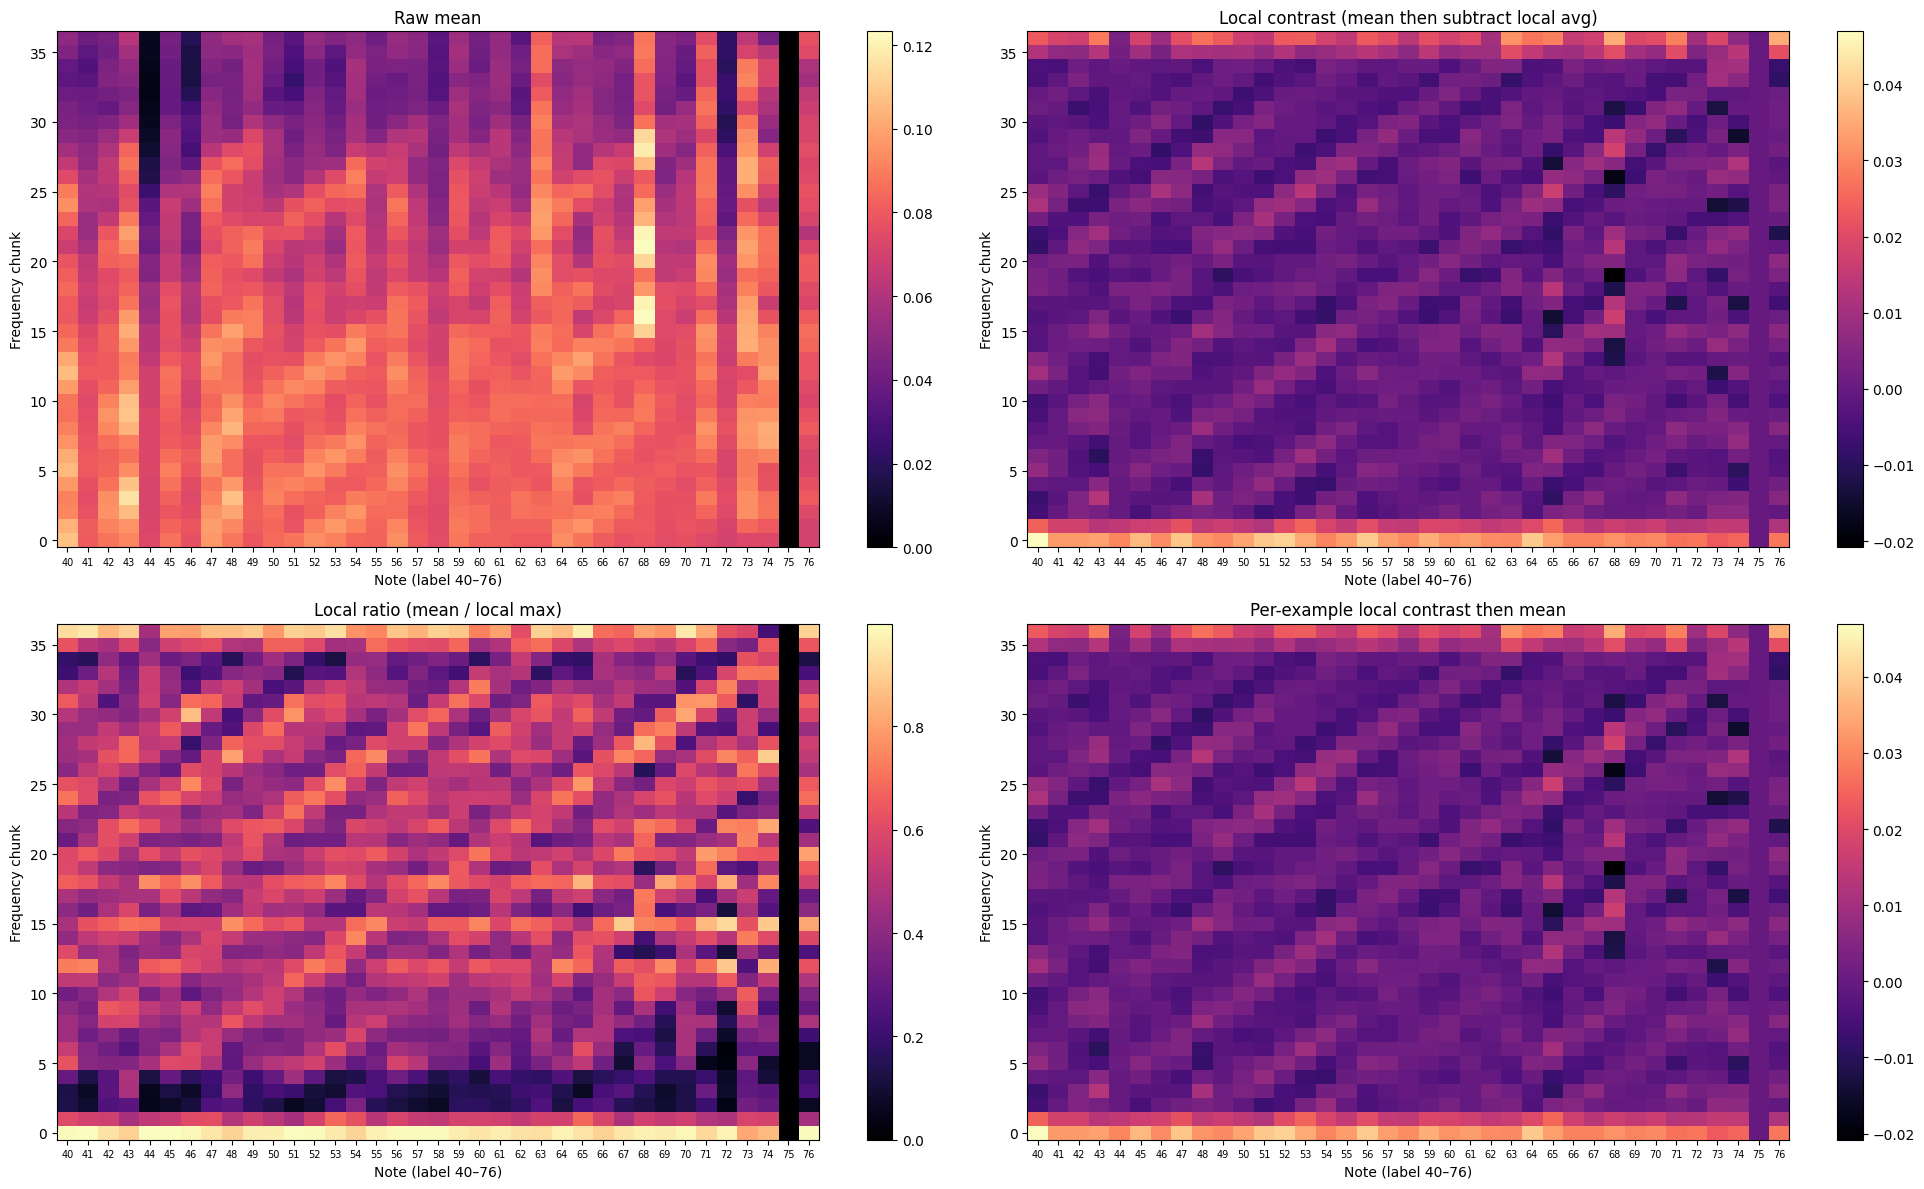

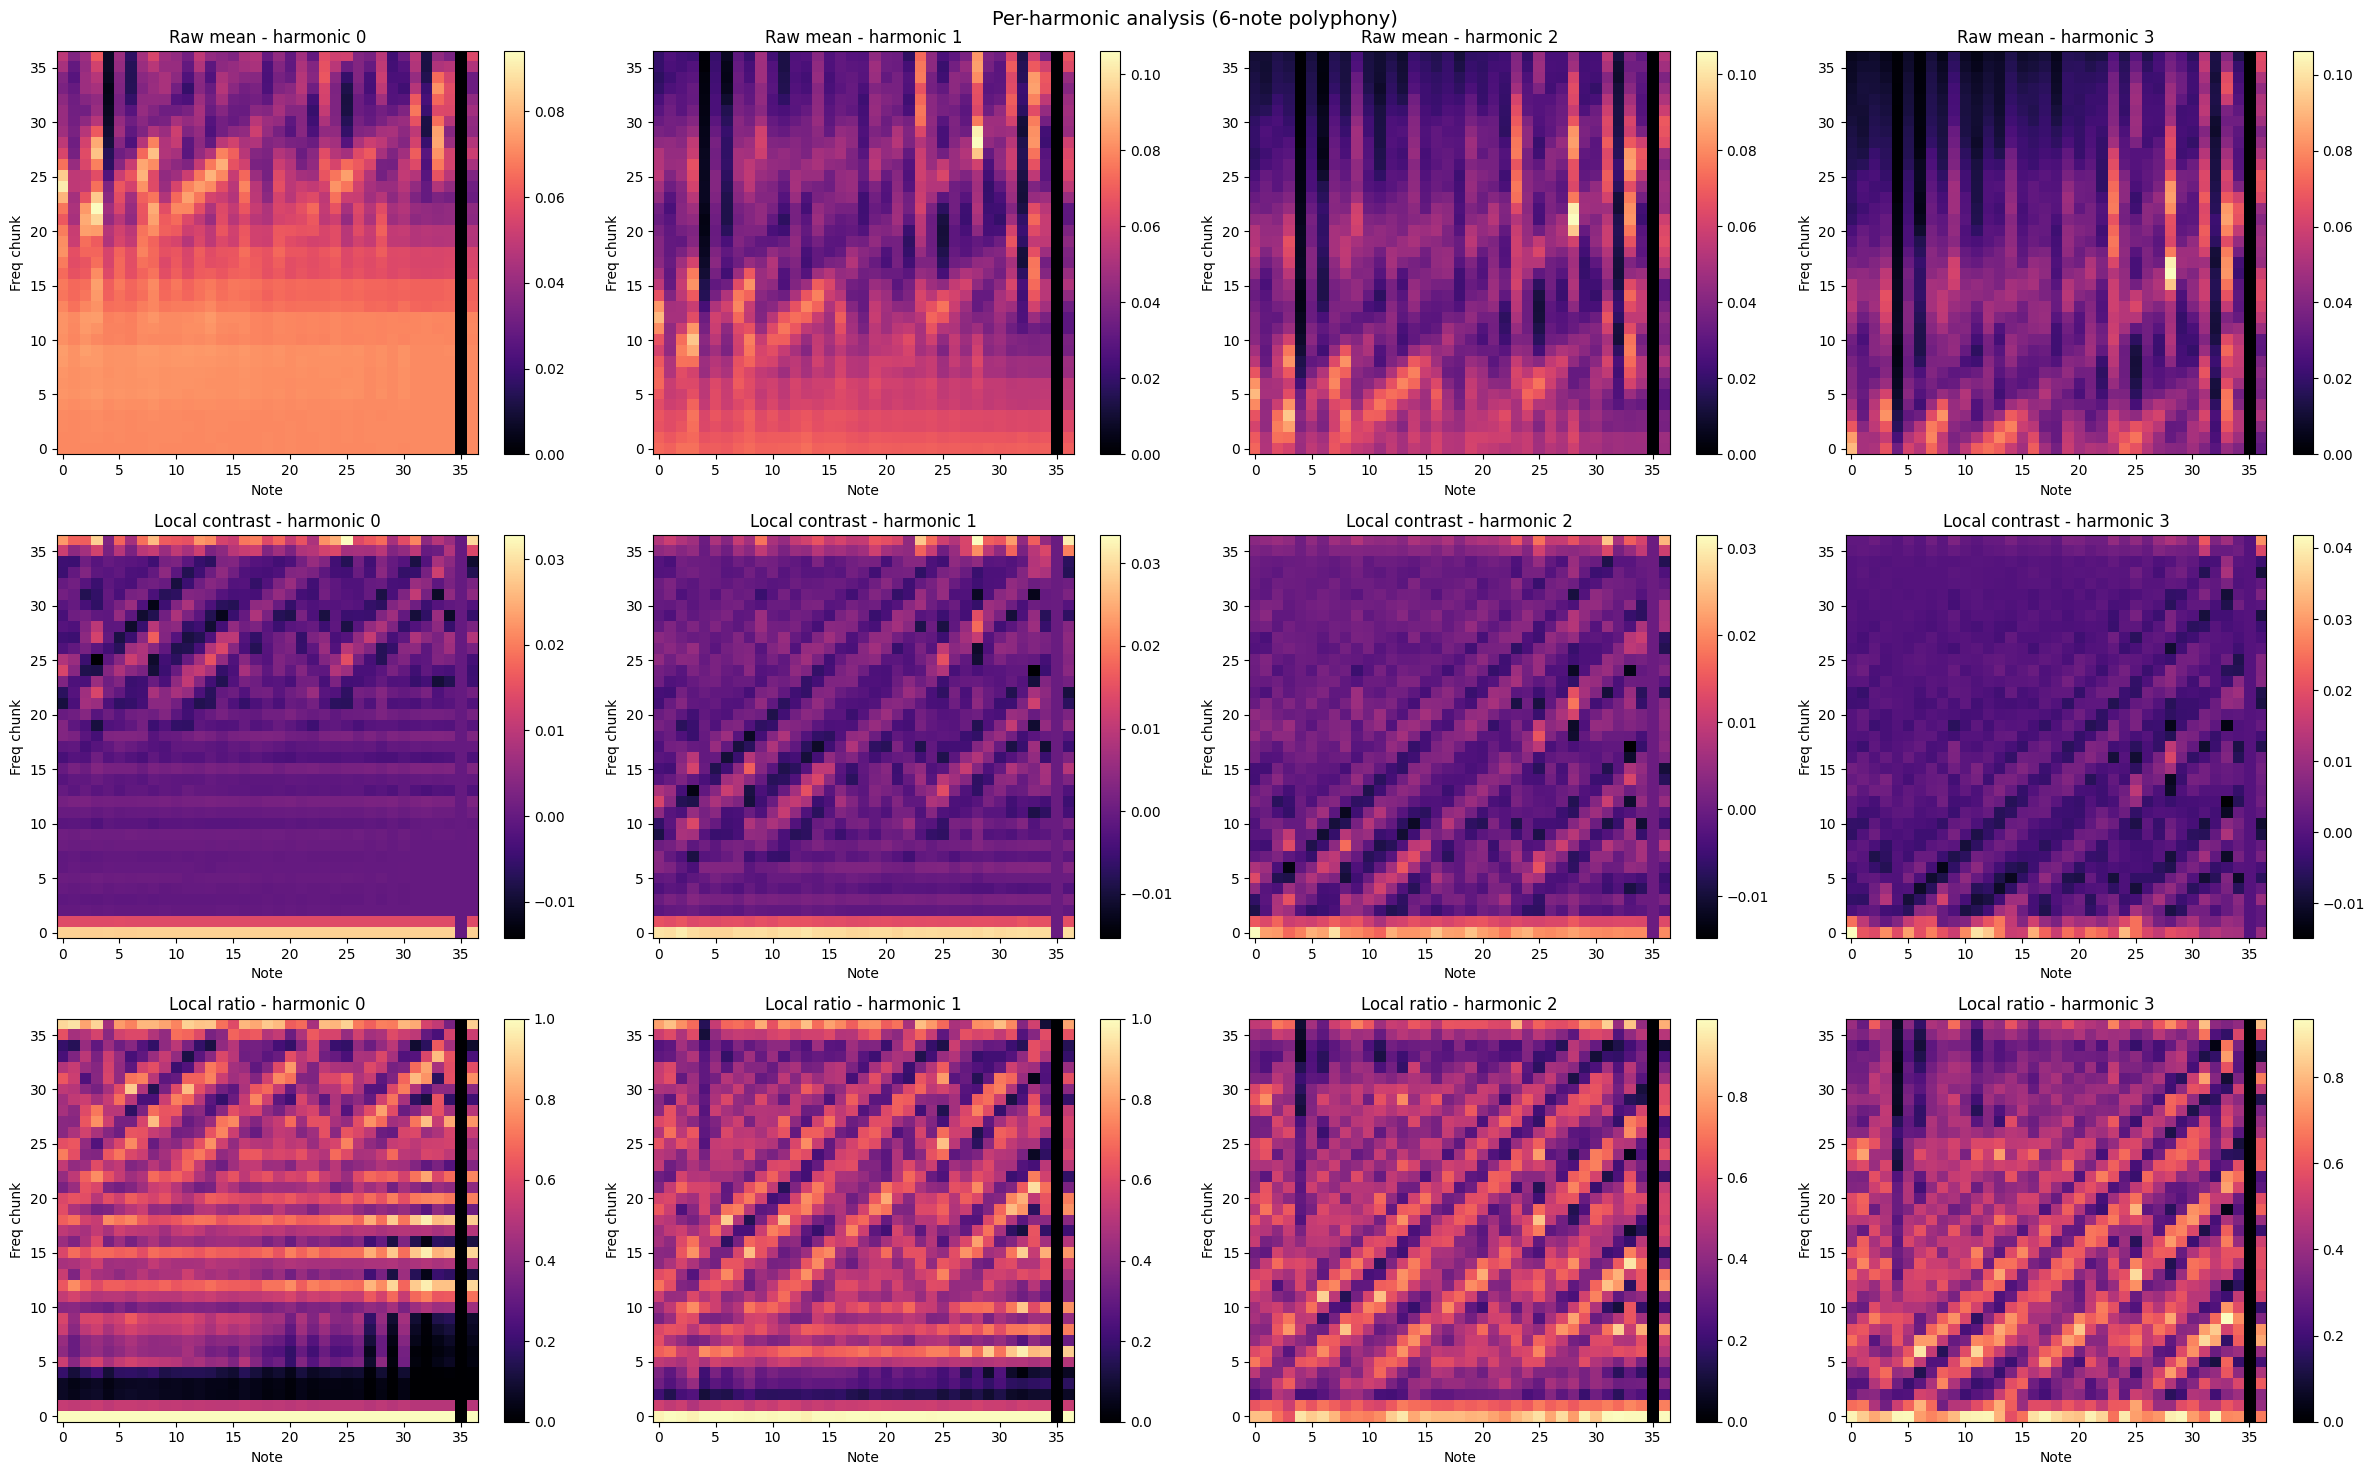

In [ ]:
# title: "Per-note mean and local contrast of chunk maxes (6-note polyphony)"
# This block computes, for each note (label 40..76), the mean of the max values in each frequency chunk across all examples where that note is active, 
# then applies local contrast and local ratio normalization to highlight which chunks are most consistently strong or variable when a particular note is active.
import numpy as np
from scipy.ndimage import maximum_filter1d,minimum_filter1d

dataset = create_dataset(input_filepaths)
dataset = filter_polyphony(dataset, 6, False,has_filtered_audio=True)

note_chunks = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4).max(axis=1)

    active = np.where(label_sub == 1)[0]
    for note in active:
        note_chunks[note].append(chunks)

# Raw mean
mean_image = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        mean_image[:, note] = np.mean(stacked, axis=0)

# Local contrast
local_contrast_image = np.zeros((37, 37))
for note in range(37):
    col = mean_image[:, note]
    kernel = np.ones(5) / 5
    local_mean = np.convolve(col, kernel, mode='same')
    local_contrast_image[:, note] = col - local_mean

# Local ratio
local_ratio_image = np.zeros((37, 37))
# for note in range(37):
#     col = mean_image[:, note]
#     local_max = maximum_filter1d(col, size=7)
#     local_max = np.maximum(local_max, 1e-8)
#     local_ratio_image[:, note] = col / local_max

# Per-example local contrast
mean_contrast_per_example = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            local_mean = np.convolve(stacked[i], kernel, mode='same')
            contrasted[i] = stacked[i] - local_mean
            local_max=maximum_filter1d(contrasted[i],7)
            local_min=minimum_filter1d(contrasted[i],7)
            local_diff = np.maximum(local_max-local_min, 1e-8)
            ratio[i]=contrasted[i]/local_diff-local_min/local_diff
            
        mean_contrast_per_example[:, note] = np.mean(contrasted, axis=0)
        local_ratio_image[:,note]=np.mean(ratio,axis=0)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, img, title in zip(
    axes.flat,
    [mean_image, local_contrast_image, local_ratio_image, mean_contrast_per_example],
    ["Raw mean", "Local contrast (mean then subtract local avg)",
     "Local ratio (mean / local max)", "Per-example local contrast then mean"]
):
    im = ax.imshow(img, aspect='auto', origin='lower', cmap='magma')
    ax.set_xlabel("Note (label 40–76)")
    ax.set_ylabel("Frequency chunk")
    ax.set_xticks(range(37))
    ax.set_xticklabels(range(40, 77), fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Full 4-harmonic resolution
note_chunks_full = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4)

    active = np.where(label_sub == 1)[0]
    for note in active:
        note_chunks_full[note].append(chunks)

mean_full = np.zeros((37, 4, 37))
contrast_full = np.zeros((37, 4, 37))
ratio_full = np.zeros((37, 4, 37))

for note in range(37):
    if len(note_chunks_full[note]) > 1:
        stacked = np.stack(note_chunks_full[note], axis=0)  # (N, 37, 4)
        mean_full[:, :, note] = np.mean(stacked, axis=0)

        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            for h in range(4):
                local_mean = np.convolve(stacked[i, :, h], kernel, mode='same')
                contrasted[i, :, h] = stacked[i, :, h] - local_mean
                local_max = maximum_filter1d(contrasted[i, :, h], 7)
                local_min = minimum_filter1d(contrasted[i, :, h], 7)
                local_diff = np.maximum(local_max - local_min, 1e-8)
                ratio[i, :, h] = contrasted[i, :, h] / local_diff - local_min / local_diff

                

        contrast_full[:, :, note] = np.mean(contrasted, axis=0)
        ratio_full[:,:,note]=np.mean(ratio,axis=0)

    # Local ratio on the mean
    # for h in range(4):
    #     col = mean_full[:, h, note]
    #     local_max = maximum_filter1d(col, size=7)
    #     local_max = np.maximum(local_max, 1e-8)
    #     ratio_full[:, h, note] = col / local_max

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
for h in range(4):
    im1 = axes[0, h].imshow(mean_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[0, h].set_title(f"Raw mean - harmonic {h}")
    axes[0, h].set_xlabel("Note")
    axes[0, h].set_ylabel("Freq chunk")
    plt.colorbar(im1, ax=axes[0, h])

    im2 = axes[1, h].imshow(contrast_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[1, h].set_title(f"Local contrast - harmonic {h}")
    axes[1, h].set_xlabel("Note")
    axes[1, h].set_ylabel("Freq chunk")
    plt.colorbar(im2, ax=axes[1, h])

    im3 = axes[2, h].imshow(ratio_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[2, h].set_title(f"Local ratio - harmonic {h}")
    axes[2, h].set_xlabel("Note")
    axes[2, h].set_ylabel("Freq chunk")
    plt.colorbar(im3, ax=axes[2, h])

plt.suptitle("Per-harmonic analysis (6-note polyphony)", fontsize=14)
plt.tight_layout()
plt.show()


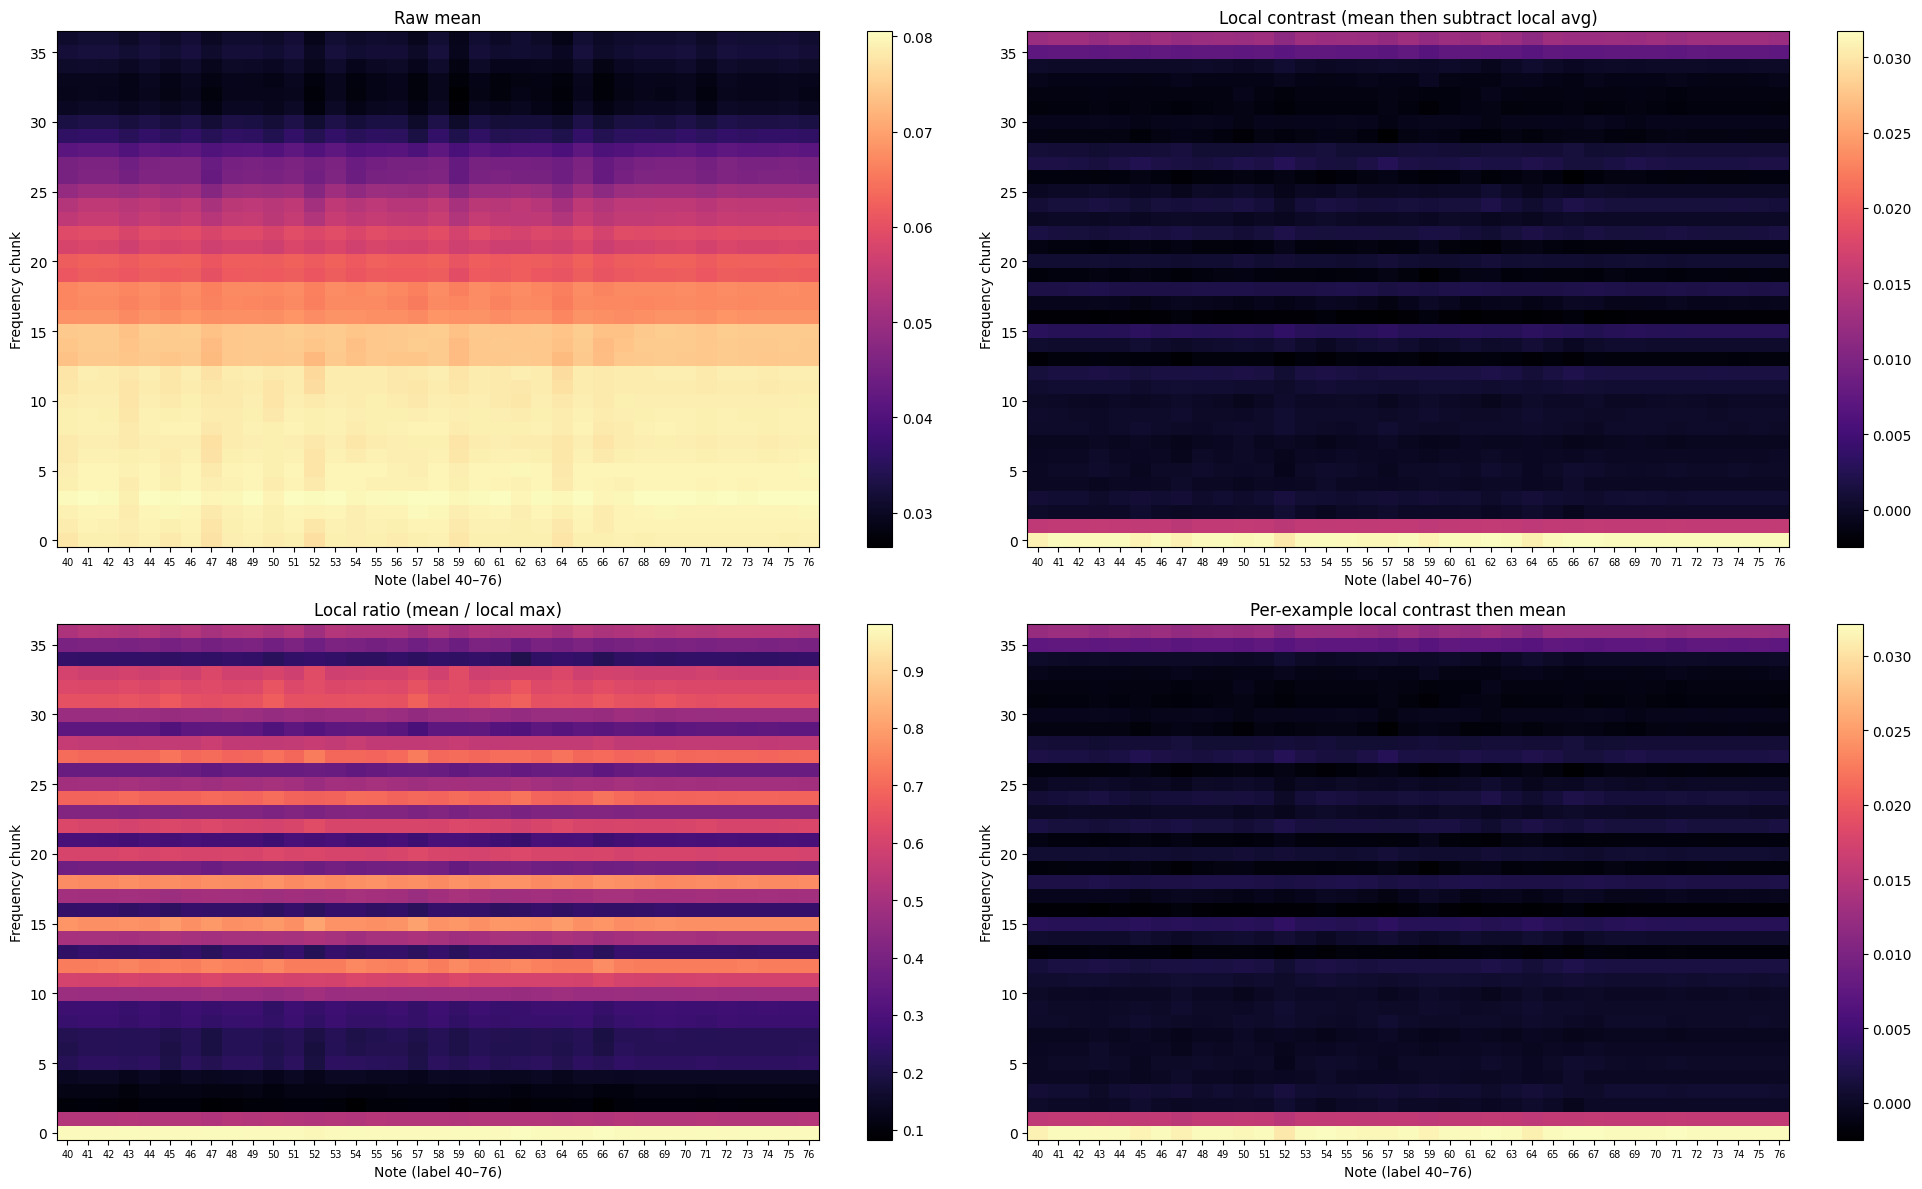

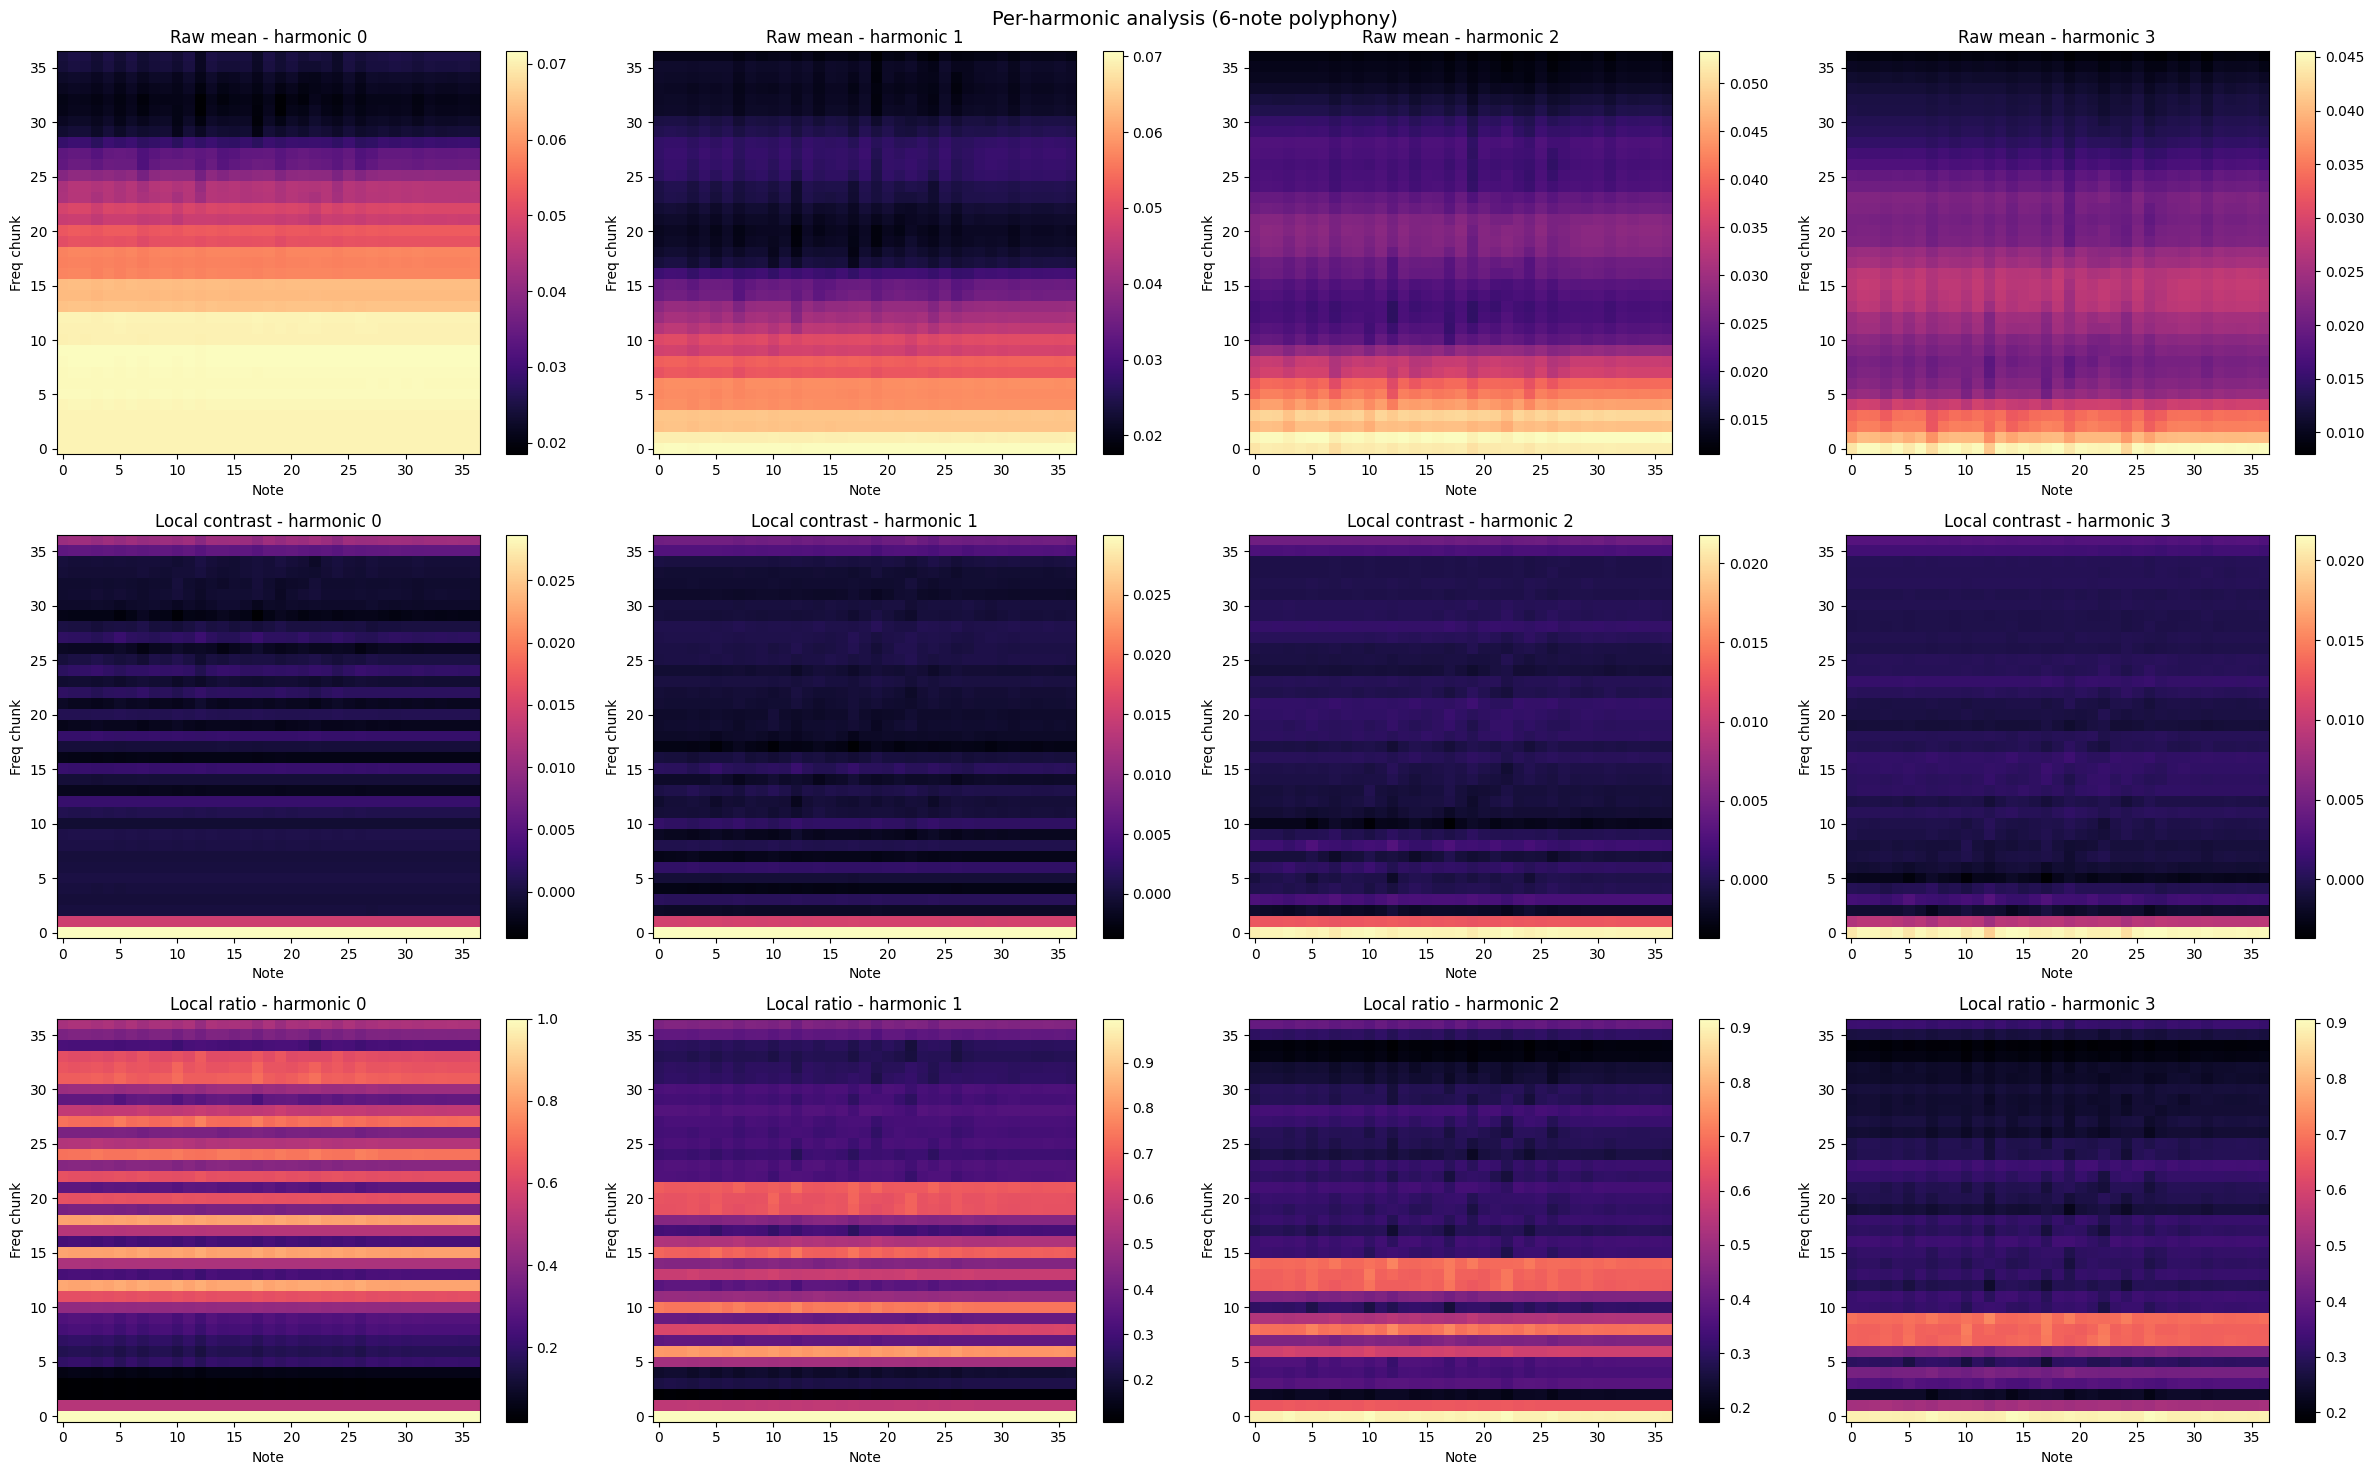

In [ ]:
# title: "Per-note mean and local contrast of chunk maxes for non-active notes (6-note polyphony)"
# This block does the same as the previous one but for non-active notes, to see if there are any chunks that are consistently strong or variable even when a note is not active. This can help identify potential confounding factors or noise patterns in the data.
# Non active notes
import numpy as np
from scipy.ndimage import maximum_filter1d,minimum_filter1d

dataset = create_dataset(input_filepaths)
dataset = filter_polyphony(dataset, 6, False,has_filtered_audio=True)

note_chunks = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4).max(axis=1)

    inactive = np.where(label_sub == 0)[0]
    for note in inactive:
        note_chunks[note].append(chunks)

# Raw mean
mean_image = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        mean_image[:, note] = np.mean(stacked, axis=0)

# Local contrast
local_contrast_image = np.zeros((37, 37))
for note in range(37):
    col = mean_image[:, note]
    kernel = np.ones(5) / 5
    local_mean = np.convolve(col, kernel, mode='same')
    local_contrast_image[:, note] = col - local_mean

# Local ratio
local_ratio_image = np.zeros((37, 37))
# for note in range(37):
#     col = mean_image[:, note]
#     local_max = maximum_filter1d(col, size=7)
#     local_max = np.maximum(local_max, 1e-8)
#     local_ratio_image[:, note] = col / local_max

# Per-example local contrast
mean_contrast_per_example = np.zeros((37, 37))
for note in range(37):
    if len(note_chunks[note]) > 1:
        stacked = np.stack(note_chunks[note], axis=0)
        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            local_mean = np.convolve(stacked[i], kernel, mode='same')
            contrasted[i] = stacked[i] - local_mean
            local_max=maximum_filter1d(contrasted[i],7)
            local_min=minimum_filter1d(contrasted[i],7)
            local_diff = np.maximum(local_max-local_min, 1e-8)
            ratio[i]=contrasted[i]/local_diff-local_min/local_diff
            
        mean_contrast_per_example[:, note] = np.mean(contrasted, axis=0)
        local_ratio_image[:,note]=np.mean(ratio,axis=0)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
for ax, img, title in zip(
    axes.flat,
    [mean_image, local_contrast_image, local_ratio_image, mean_contrast_per_example],
    ["Raw mean", "Local contrast (mean then subtract local avg)",
     "Local ratio (mean / local max)", "Per-example local contrast then mean"]
):
    im = ax.imshow(img, aspect='auto', origin='lower', cmap='magma')
    ax.set_xlabel("Note (label 40–76)")
    ax.set_ylabel("Frequency chunk")
    ax.set_xticks(range(37))
    ax.set_xticklabels(range(40, 77), fontsize=7)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Full 4-harmonic resolution
note_chunks_full = {i: [] for i in range(37)}

for audio, label in dataset:
    audio_max = audio.numpy().max(axis=1)
    label_sub = label.numpy()[40:77]
    chunks = audio_max.reshape(37, 4)

    inactive = np.where(label_sub == 0)[0]
    for note in inactive:
        note_chunks_full[note].append(chunks)

mean_full = np.zeros((37, 4, 37))
contrast_full = np.zeros((37, 4, 37))
ratio_full = np.zeros((37, 4, 37))

for note in range(37):
    if len(note_chunks_full[note]) > 1:
        stacked = np.stack(note_chunks_full[note], axis=0)  # (N, 37, 4)
        mean_full[:, :, note] = np.mean(stacked, axis=0)

        kernel = np.ones(5) / 5
        contrasted = np.zeros_like(stacked)
        ratio=np.zeros_like(stacked)
        for i in range(len(stacked)):
            for h in range(4):
                local_mean = np.convolve(stacked[i, :, h], kernel, mode='same')
                contrasted[i, :, h] = stacked[i, :, h] - local_mean
                local_max = maximum_filter1d(contrasted[i, :, h], 7)
                local_min = minimum_filter1d(contrasted[i, :, h], 7)
                local_diff = np.maximum(local_max - local_min, 1e-8)
                ratio[i, :, h] = contrasted[i, :, h] / local_diff - local_min / local_diff

                

        contrast_full[:, :, note] = np.mean(contrasted, axis=0)
        ratio_full[:,:,note]=np.mean(ratio,axis=0)

    # Local ratio on the mean
    # for h in range(4):
    #     col = mean_full[:, h, note]
    #     local_max = maximum_filter1d(col, size=7)
    #     local_max = np.maximum(local_max, 1e-8)
    #     ratio_full[:, h, note] = col / local_max

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
for h in range(4):
    im1 = axes[0, h].imshow(mean_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[0, h].set_title(f"Raw mean - harmonic {h}")
    axes[0, h].set_xlabel("Note")
    axes[0, h].set_ylabel("Freq chunk")
    plt.colorbar(im1, ax=axes[0, h])

    im2 = axes[1, h].imshow(contrast_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[1, h].set_title(f"Local contrast - harmonic {h}")
    axes[1, h].set_xlabel("Note")
    axes[1, h].set_ylabel("Freq chunk")
    plt.colorbar(im2, ax=axes[1, h])

    im3 = axes[2, h].imshow(ratio_full[:, h, :], aspect='auto', origin='lower', cmap='magma')
    axes[2, h].set_title(f"Local ratio - harmonic {h}")
    axes[2, h].set_xlabel("Note")
    axes[2, h].set_ylabel("Freq chunk")
    plt.colorbar(im3, ax=axes[2, h])

plt.suptitle("Per-harmonic analysis (6-note polyphony)", fontsize=14)
plt.tight_layout()
plt.show()
